In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
df = pd.read_csv(url)
print(df.head())


    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"    #it loads the data from the url
df = pd.read_csv(url)

print(df.head())
print(df.info())
print(df.columns)

    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2 

In [4]:
df = df[["mpg", "horsepower"]]


In [5]:
print(df.isnull().sum())


mpg           0
horsepower    6
dtype: int64


In [6]:
df = df.dropna()


In [7]:
print(df.isnull().sum())

mpg           0
horsepower    0
dtype: int64


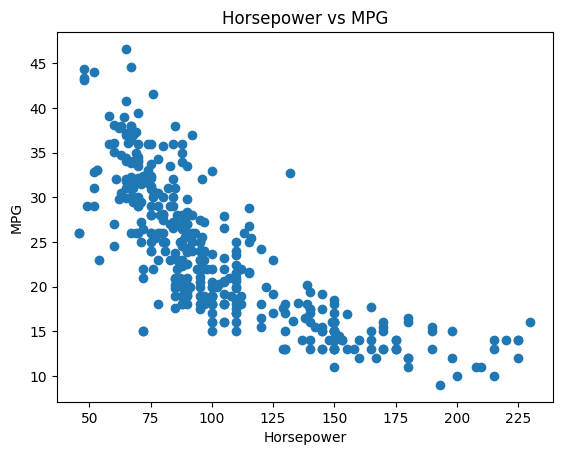

In [ ]:
df["horsepower"] = pd.to_numeric(df["horsepower"])
x = df["horsepower"] #independent variable
y = df["mpg"]  #dependent variable
X = x.values.reshape(-1, 1)
y = y.values
plt.scatter(x, y)
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Horsepower vs MPG")
plt.show()



In [12]:
print(df.corr())


                 mpg  horsepower
mpg         1.000000   -0.778427
horsepower -0.778427    1.000000


In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
#from sklearn.metrics import r2_score, mean_squared_error
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)
print("Intercept (b0):", model.intercept_)
print("Slope (b1):", model.coef_[0])
y_pred = model.predict(X_test)

# print("R2 Score:", r2_score(y_test, y_pred))
# print("MSE:", mean_squared_error(y_test, y_pred))


Intercept (b0): 40.606097600118346
Slope (b1): -0.16259724322918453


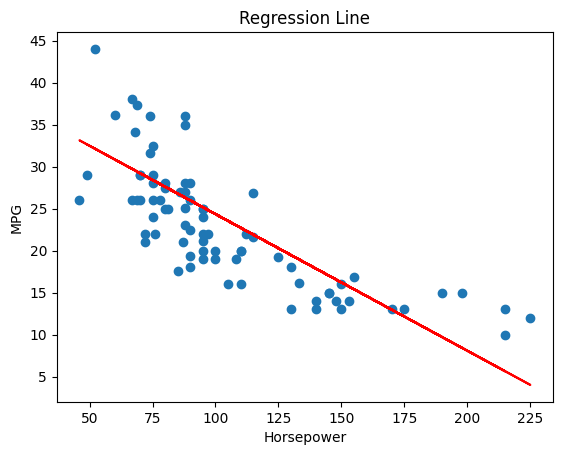

In [18]:
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred, color='red')
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Regression Line")
plt.show()


In [19]:
# Convert to numpy arrays
x = df["horsepower"].values
y = df["mpg"].values

# Means
x_mean = np.mean(x)
y_mean = np.mean(y)

# Calculate slope
numerator = np.sum((x - x_mean) * (y - y_mean))
denominator = np.sum((x - x_mean) ** 2)

b1 = numerator / denominator

# Calculate intercept
b0 = y_mean - b1 * x_mean

print("Manual Intercept:", b0)
print("Manual Slope:", b1)


Manual Intercept: 39.93586102117047
Manual Slope: -0.15784473335365362


In [20]:
def predict(x_value):
    return b0 + b1 * x_value

print("Predicted MPG for 100 horsepower:", predict(100))


Predicted MPG for 100 horsepower: 24.151387685805105
